# Question 2
What factors go into making an asteroid potentially hazardous or not?

First we sort the data by `miss_distance_km` to find the NEOs that are closest to Earth. Then we run a series of regressions tests to determine which variables may be influencing the miss distance.

printing first 10 rows
   id neo_reference_id         name                                                     nasa_jpl_url  absolute_magnitude_h  estimated_diameter_min_km  estimated_diameter_max_km  is_potentially_hazardous_asteroid close_approach_date close_approach_date_full  relative_velocity_kph  miss_distance_km orbiting_body  is_sentry_object          ingested_at
0   1          3745999  (2016 ES84)   https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=3745999                20.310                   0.230438                   0.515276                                  0          2026-04-01        2026-Apr-01 17:14          122481.837524      6.518220e+07         Earth                 0  2026-04-01 23:33:49
1   2          3802103   (2018 FK5)   https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=3802103                28.300                   0.005815                   0.013003                                  0          2026-04-01        2026-Apr-01 21:06           36109.68

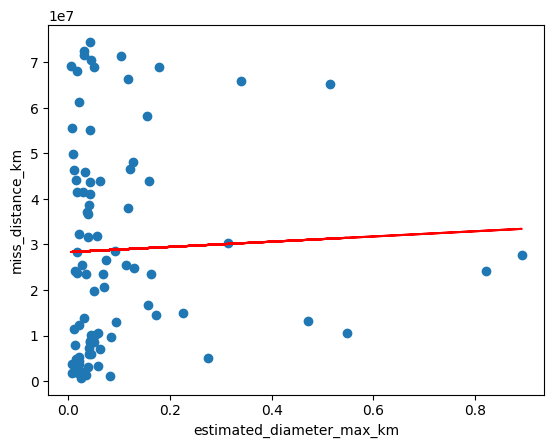

In [50]:
%run ./main.ipynb

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# print(df_all.size)


print("printing first 10 rows")
print(df_all.head(10).to_string())

print("Getting asteroids marked as potentially hazardous:")
df_hazardous = df_all.query("is_potentially_hazardous_asteroid != 0")
print(df_hazardous.size)

df_near_miss = df_all.sort_values(by="miss_distance_km")
print("printing first 10 rows of near misses")
print(df_near_miss.head(10).to_string())

df_near_miss.plot.scatter(x="estimated_diameter_max_km", y="miss_distance_km")

# linear regression with scipy

diam = np.array(df_all["estimated_diameter_max_km"])
miss = np.array(df_all["miss_distance_km"])

slope, intercept, r_value, p_value, std_err = stats.linregress(diam, miss)
plt.scatter(diam, miss)
plt.plot(diam, intercept + slope * diam, 'r', label='fitted line')
plt.show()